# Muhammad Haissam

## Week 2: Building, Evaluating, and Interpreting ML Models

**University:** Quaid-i-Azam University, Islamabad

**Department:** Electronics

**Date:** 4 October 2026

**Project:** ML-Powered Customer Analytics

**Objective:** Train and compare customer churn prediction models,
interpret their predictions, and evaluate the trade-off between
catching churners and raising false alarms.

**Dataset:** Telco Customer Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

print("Week 2 libraries imported successfully!")

Week 2 libraries imported successfully!


## 1. Data Preparation and Baseline

### 1.1 Loading and Cleaning

In [2]:
dataset_path = "/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv"

df = pd.read_csv(dataset_path)

# Convert TotalCharges from text to numbers
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"], errors="coerce"
)

# Inspect missing charges before filling them
missing_charges = df["TotalCharges"].isna()

print("Rows with missing TotalCharges:", missing_charges.sum())

display(
    df.loc[
        missing_charges,
        ["customerID", "tenure", "TotalCharges"]
    ]
)

# Week 1 showed these customers all had zero months of tenure
df["TotalCharges"] = df["TotalCharges"].fillna(0)

print("Dataset shape:", df.shape)
print("Remaining missing values:", df.isna().sum().sum())

Rows with missing TotalCharges: 11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,NaN
753,3115-CZMZD,0,NaN
936,5709-LVOEQ,0,NaN
1082,4367-NUYAO,0,NaN
1340,1371-DWPAZ,0,NaN
3331,7644-OMVMY,0,NaN
3826,3213-VVOLG,0,NaN
4380,2520-SGTTA,0,NaN
5218,2923-ARZLG,0,NaN
6670,4075-WKNIU,0,NaN


Dataset shape: (7043, 21)
Remaining missing values: 0


### Cleaning Decision

TotalCharges was converted from text to numbers. The 11 missing values
belonged to customers with zero months of tenure, so I filled them
with 0 for modelling, assuming they had not yet accumulated charges.

This differs from Week 1, where the values remained missing during
exploration.

### 1.2 Features, Target, Train/Test Split, and Baseline

In [3]:
def build_features(data):
    # Remove the identifier and the answer we want to predict
    features = data.drop(columns=["customerID", "Churn"])

    # Convert text categories into numerical indicator columns
    return pd.get_dummies(
        features, drop_first=True
    ).astype(float)


X = build_features(df)
y = (df["Churn"] == "Yes").astype(int)

print("Feature table shape:", X.shape)

# Keep the churn proportions similar in training and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(
    f"Training: {len(X_train)} customers; "
    f"churn rate: {y_train.mean():.2%}"
)

print(
    f"Testing: {len(X_test)} customers; "
    f"churn rate: {y_test.mean():.2%}"
)

# Baseline: always predict the most common training class
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)

baseline_predictions = dummy.predict(X_test)

print(
    "Baseline accuracy:",
    round(accuracy_score(y_test, baseline_predictions), 4)
)

print(
    "Baseline churn recall:",
    round(recall_score(y_test, baseline_predictions), 4)
)

Feature table shape: (7043, 30)
Training: 5634 customers; churn rate: 26.54%
Testing: 1409 customers; churn rate: 26.54%
Baseline accuracy: 0.7346
Baseline churn recall: 0.0


The baseline always predicts that a customer will stay. It achieves 73.46% accuracy but catches none of the customers who churned. This happens because staying is the more common outcome. The baseline shows why accuracy alone is not enough: a useful model must also identify customers who leave.

## 2. Logistic Regression

Logistic Regression estimates the probability that a customer will churn.
The scaler is fitted using training data inside a Pipeline.

In [4]:
# Scale the inputs and train the classifier
lr = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression classification report:")
print(classification_report(
    y_test, y_pred_lr,
    target_names=["Stay", "Churn"],
    digits=3,
    zero_division=0
))

# Interpret model coefficients
scaler = lr.named_steps["scale"]
model = lr.named_steps["model"]
weights = model.coef_[0]

coef = pd.DataFrame({
    "feature": X.columns,
    "weight": weights,
    "odds_ratio_per_SD": np.exp(weights),
    "odds_ratio_per_original_unit": np.exp(
        weights / scaler.scale_
    )
})

risk = coef[coef["weight"] > 0].nlargest(3, "weight")
protective = coef[coef["weight"] < 0].nsmallest(3, "weight")

print("Largest positive standardized coefficients:")
display(risk.round(3))

print("Largest negative standardized coefficients:")
display(protective.round(3))

# Reproduce one prediction using the sigmoid formula
x0 = scaler.transform(X_test.iloc[[0]])
z = float(model.intercept_[0] + (x0 @ weights)[0])
manual_probability = 1 / (1 + np.exp(-z))

print(f"Linear score z: {z:.4f}")
print(f"Manual sigmoid probability: {manual_probability:.6f}")
print(f"Model probability: {y_prob_lr[0]:.6f}")
print(
    "Probabilities match:",
    np.isclose(manual_probability, y_prob_lr[0])
)

risk_text = "; ".join(
    f"{row.feature} (odds ratio {row.odds_ratio_per_SD:.3f})"
    for row in risk.itertuples()
)

protective_text = "; ".join(
    f"{row.feature} (odds ratio {row.odds_ratio_per_SD:.3f})"
    for row in protective.itertuples()
)

tenure_or = float(
    coef.loc[
        coef["feature"] == "tenure",
        "odds_ratio_per_original_unit"
    ].iloc[0]
)



Logistic Regression classification report:
              precision    recall  f1-score   support

        Stay      0.851     0.894     0.872      1035
       Churn      0.658     0.567     0.609       374

    accuracy                          0.807      1409
   macro avg      0.755     0.730     0.741      1409
weighted avg      0.800     0.807     0.802      1409

Largest positive standardized coefficients:


,feature,weight,odds_ratio_per_SD,odds_ratio_per_original_unit
10,InternetService_Fiber optic,0.776,2.173,4.775
3,TotalCharges,0.514,1.672,1.000
23,StreamingMovies_Yes,0.257,1.293,1.694


Largest negative standardized coefficients:


,feature,weight,odds_ratio_per_SD,odds_ratio_per_original_unit
1,tenure,-1.237,0.290,0.951
2,MonthlyCharges,-0.920,0.398,0.970
25,Contract_Two year,-0.587,0.556,0.254


Linear score z: -3.0555
Manual sigmoid probability: 0.044982
Model probability: 0.044982
Probabilities match: True


### Baseline Interpretation

The baseline model predicts that every customer will stay. It reaches 73.46% accuracy because staying is the more common outcome, but it identifies none of the customers who actually churned. This gives us a useful starting point: a real model must do more than always predict the majority class.

## 3. Confusion Matrix and Evaluation Metrics

The confusion matrix shows correct predictions, false alarms,
and customers whose churn was missed.


TN=925, FP=110, FN=162, TP=212


,Metric,Manual,Scikit-learn
0,Precision,0.6584,0.6584
1,Recall,0.5668,0.5668
2,F1,0.6092,0.6092


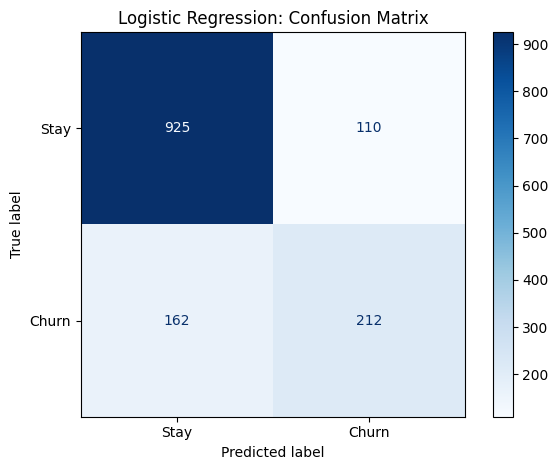

In [5]:
cm = confusion_matrix(y_test, y_pred_lr, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

precision_manual = tp / (tp + fp) if tp + fp else 0
recall_manual = tp / (tp + fn) if tp + fn else 0

f1_manual = (
    2 * precision_manual * recall_manual
    / (precision_manual + recall_manual)
    if precision_manual + recall_manual else 0
)

print(f"TN={tn}, FP={fp}, FN={fn}, TP={tp}")

manual_metrics = pd.DataFrame({
    "Metric": ["Precision", "Recall", "F1"],
    "Manual": [
        precision_manual,
        recall_manual,
        f1_manual
    ],
    "Scikit-learn": [
        precision_score(y_test, y_pred_lr, zero_division=0),
        recall_score(y_test, y_pred_lr, zero_division=0),
        f1_score(y_test, y_pred_lr, zero_division=0)
    ]
})

display(manual_metrics.round(4))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Stay", "Churn"]
).plot(cmap="Blues")

plt.title("Logistic Regression: Confusion Matrix")
plt.tight_layout()
plt.show()



### Confusion Matrix Interpretation

The model correctly classified 925 customers who stayed and 212 customers who churned. It incorrectly warned about 110 customers who stayed, and it missed 162 customers who churned.

The precision for churn was 0.658, so about two thirds of the customers flagged by the model really churned. The recall was 0.567, which means the model found 56.7% of all churners. The manually calculated precision, recall, and F1 score matched the values from scikit-learn, which confirms that the metric calculations were correct.

## 4. ROC-AUC, Decision Thresholds, and Business Cost

A decision threshold converts a churn probability into a class prediction.
This exercise assumes a missed churner costs PKR 6,000 and an unnecessary
retention offer costs PKR 1,000.

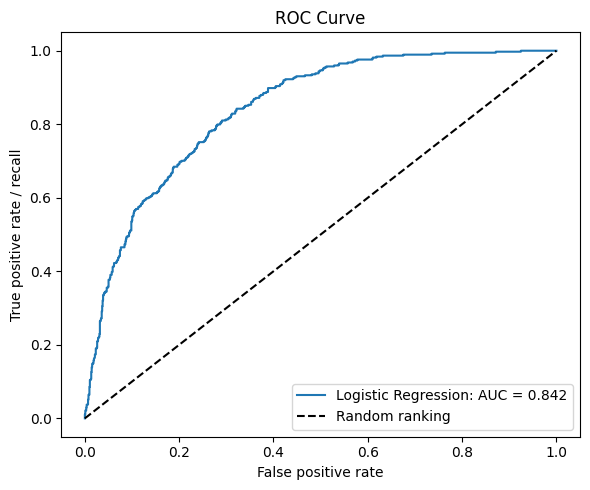

,threshold,flagged,precision,recall,f1
0,0.2,685,0.467,0.856,0.604
1,0.3,543,0.519,0.754,0.615
2,0.4,441,0.567,0.668,0.613
3,0.5,322,0.658,0.567,0.609
4,0.6,210,0.710,0.398,0.510
5,0.7,89,0.730,0.174,0.281


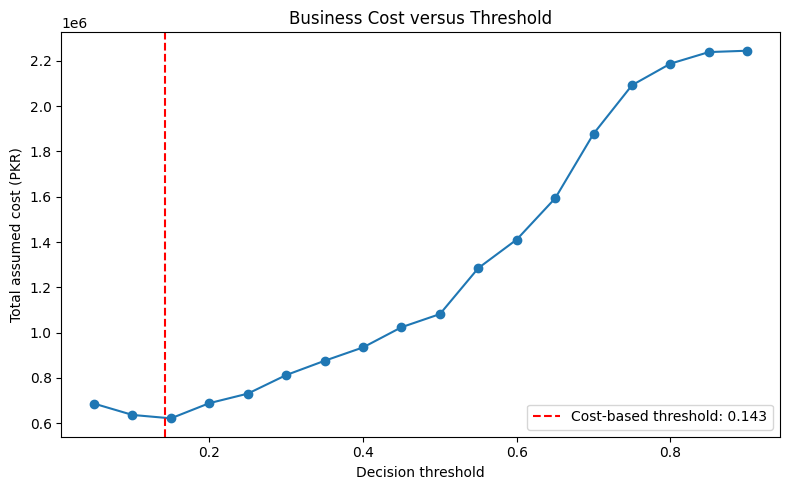

Theoretical threshold: 0.1429
Lowest-cost tested threshold: 0.15
Cost at threshold 0.5: 1082000
Cost at chosen threshold: 619000
Extra churners caught: 132
Extra false alarms: 329


In [6]:
auc_lr = roc_auc_score(y_test, y_prob_lr)
fpr, tpr, _ = roc_curve(y_test, y_prob_lr)

plt.figure(figsize=(6, 5))
plt.plot(
    fpr, tpr,
    label=f"Logistic Regression: AUC = {auc_lr:.3f}"
)
plt.plot([0, 1], [0, 1], "k--", label="Random ranking")
plt.xlabel("False positive rate")
plt.ylabel("True positive rate / recall")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

# Compare several decision thresholds
threshold_rows = []

for threshold in [0.2, 0.3, 0.4, 0.5, 0.6, 0.7]:
    prediction = (y_prob_lr >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "flagged": int(prediction.sum()),
        "precision": precision_score(
            y_test, prediction, zero_division=0
        ),
        "recall": recall_score(
            y_test, prediction, zero_division=0
        ),
        "f1": f1_score(
            y_test, prediction, zero_division=0
        )
    })

threshold_table = pd.DataFrame(threshold_rows)
display(threshold_table.round(3))

# Costs are assumptions supplied by the lab
C_FN = 6000
C_FP = 1000

def total_cost(threshold):
    prediction = (y_prob_lr >= threshold).astype(int)
    counts = confusion_matrix(
        y_test, prediction, labels=[0, 1]
    ).ravel()

    return int(counts[2] * C_FN + counts[1] * C_FP)


thresholds = np.round(np.arange(0.05, 0.95, 0.05), 2)
costs = [total_cost(t) for t in thresholds]

empirical_best_t = float(thresholds[np.argmin(costs)])
theoretical_t = C_FP / (C_FP + C_FN)

# Choose from the stated costs rather than the best test-set result
chosen_threshold = theoretical_t

plt.figure(figsize=(8, 5))
plt.plot(thresholds, costs, marker="o")
plt.axvline(
    theoretical_t,
    linestyle="--",
    color="red",
    label=f"Cost-based threshold: {theoretical_t:.3f}"
)
plt.xlabel("Decision threshold")
plt.ylabel("Total assumed cost (PKR)")
plt.title("Business Cost versus Threshold")
plt.legend()
plt.tight_layout()
plt.show()

cost_prediction = (
    y_prob_lr >= chosen_threshold
).astype(int)

tn_cost, fp_cost, fn_cost, tp_cost = confusion_matrix(
    y_test, cost_prediction, labels=[0, 1]
).ravel()

print(f"Theoretical threshold: {theoretical_t:.4f}")
print(f"Lowest-cost tested threshold: {empirical_best_t:.2f}")
print("Cost at threshold 0.5:", total_cost(0.5))
print("Cost at chosen threshold:", total_cost(chosen_threshold))
print("Extra churners caught:", int(tp_cost - tp))
print("Extra false alarms:", int(fp_cost - fp))



### Threshold and Business Cost Interpretation

The ROC-AUC score was 0.842, which shows that the model can rank likely churners reasonably well. With the usual threshold of 0.5, the model catches 56.7% of churners.

For this problem, missing a churner costs PKR 6,000, while contacting a customer unnecessarily costs PKR 1,000. Because a missed churner is six times more expensive, the cost-based threshold is:

`1000 / (1000 + 6000) = 0.1429`

At this lower threshold, recall increases to 0.920. The model catches 132 additional churners, although it also creates 329 more false alarms. The estimated cost falls from PKR 1,082,000 at the 0.5 threshold to PKR 619,000 at the cost-based threshold. I selected this threshold because the business cost makes finding churners more important than avoiding every unnecessary offer.


## 5. Decision Trees and Random Forest

I compare training and test accuracy across tree depths, inspect a shallow
tree, and train a Random Forest. The depth sweep is exploratory.

,max_depth,train,test
0,1,0.735,0.735
1,2,0.791,0.787
2,3,0.791,0.787
3,4,0.793,0.796
4,5,0.802,0.794
5,6,0.811,0.801
6,8,0.836,0.783
7,10,0.873,0.755
8,15,0.969,0.742
9,None,0.998,0.726


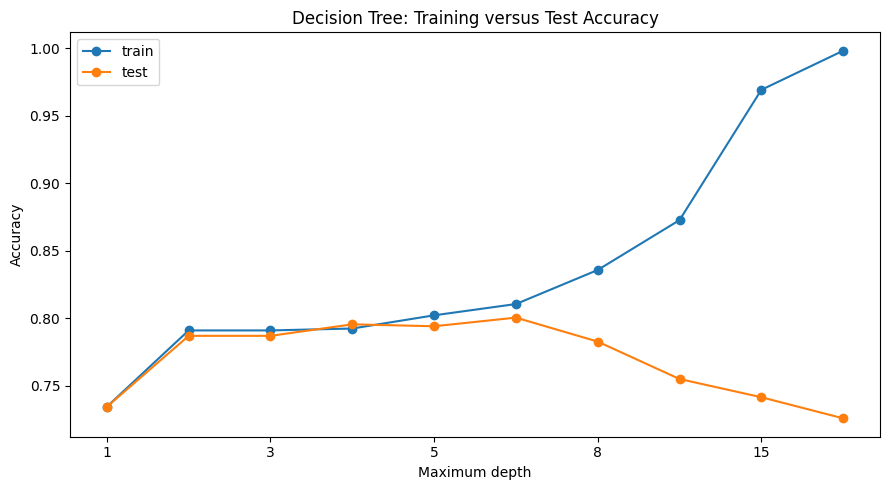

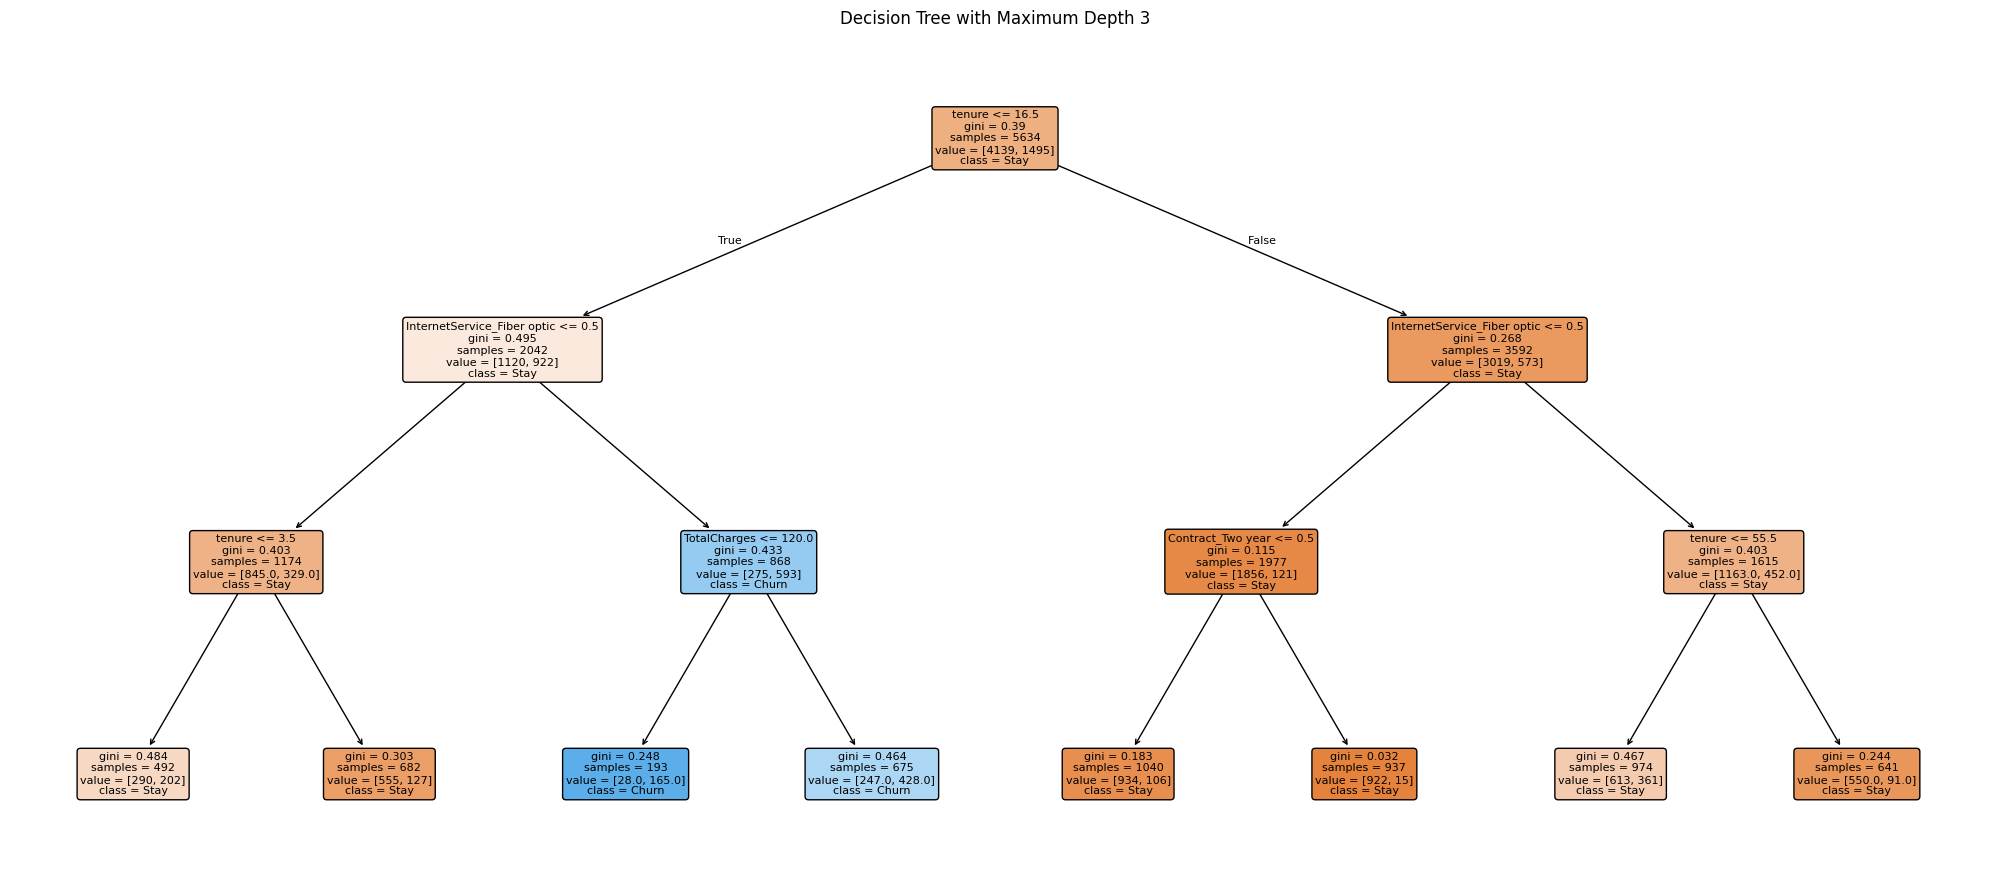

Manual root Gini: 0.389882
Tree root Gini: 0.389882
Random Forest OOB accuracy: 0.800
Random Forest test accuracy: 0.806
Random Forest test AUC: 0.843


,feature,mdi,permutation,permutation_std,mdi_rank,permutation_rank
1,tenure,0.1900,0.0406,0.0023,1.0,1.0
3,TotalCharges,0.1672,0.0194,0.0019,2.0,2.0
25,Contract_Two year,0.0578,0.0165,0.0026,6.0,3.0
10,InternetService_Fiber optic,0.0715,0.0138,0.0046,4.0,4.0
24,Contract_One year,0.0336,0.0061,0.0020,8.0,5.0
28,PaymentMethod_Electronic check,0.0607,0.0036,0.0010,5.0,6.0
26,PaperlessBilling_Yes,0.0213,0.0014,0.0015,10.0,7.0
0,SeniorCitizen,0.0117,0.0014,0.0009,22.0,8.0
9,MultipleLines_Yes,0.0157,0.0010,0.0007,13.0,9.0
19,TechSupport_Yes,0.0228,0.0010,0.0010,9.0,10.0


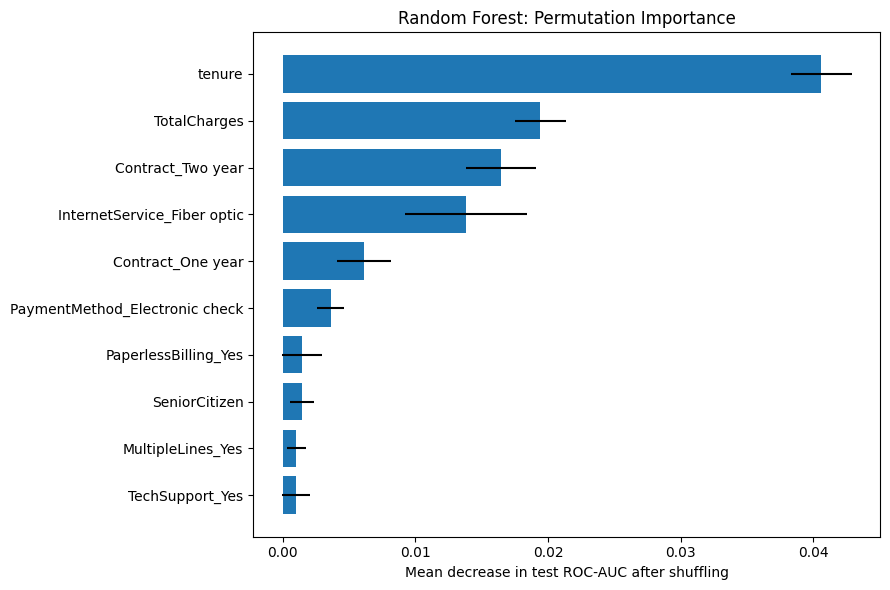

In [7]:
# Examine tree depth and overfitting
depths = [1, 2, 3, 4, 5, 6, 8, 10, 15, None]
depth_rows = []

for depth in depths:
    tree = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    tree.fit(X_train, y_train)

    depth_rows.append({
        "max_depth": str(depth),
        "train": tree.score(X_train, y_train),
        "test": tree.score(X_test, y_test)
    })

depth_df = pd.DataFrame(depth_rows)
display(depth_df.round(3))

depth_df.plot(
    x="max_depth",
    y=["train", "test"],
    marker="o",
    figsize=(9, 5)
)
plt.title("Decision Tree: Training versus Test Accuracy")
plt.xlabel("Maximum depth")
plt.ylabel("Accuracy")
plt.tight_layout()
plt.show()

# Fixed, regularized tree for the comparison table
dt5 = DecisionTreeClassifier(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
).fit(X_train, y_train)

y_pred_dt = dt5.predict(X_test)
y_prob_dt = dt5.predict_proba(X_test)[:, 1]

# Shallow tree for a readable diagram
dt3 = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
).fit(X_train, y_train)

plt.figure(figsize=(20, 9))
plot_tree(
    dt3,
    feature_names=list(X.columns),
    class_names=["Stay", "Churn"],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree with Maximum Depth 3")
plt.tight_layout()
plt.show()

# Calculate root Gini manually
root_values = dt3.tree_.value[0, 0]
root_proportions = root_values / root_values.sum()

gini_manual = 1 - np.sum(root_proportions ** 2)
gini_tree = dt3.tree_.impurity[0]

print(f"Manual root Gini: {gini_manual:.6f}")
print(f"Tree root Gini: {gini_tree:.6f}")

# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=5,
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_prob_rf)

print(f"Random Forest OOB accuracy: {rf.oob_score_:.3f}")
print(f"Random Forest test accuracy: {rf.score(X_test, y_test):.3f}")
print(f"Random Forest test AUC: {auc_rf:.3f}")

# Compare two kinds of feature importance
pi = permutation_importance(
    rf,
    X_test,
    y_test,
    scoring="roc_auc",
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

importance = pd.DataFrame({
    "feature": X.columns,
    "mdi": rf.feature_importances_,
    "permutation": pi.importances_mean,
    "permutation_std": pi.importances_std
})

importance["mdi_rank"] = importance["mdi"].rank(
    ascending=False, method="min"
)
importance["permutation_rank"] = importance["permutation"].rank(
    ascending=False, method="min"
)

importance = importance.sort_values(
    "permutation", ascending=False
)

display(importance.head(10).round(4))

top_importance = importance.head(10).sort_values("permutation")
plt.figure(figsize=(9, 6))
plt.barh(
    top_importance["feature"],
    top_importance["permutation"],
    xerr=top_importance["permutation_std"]
)
plt.xlabel("Mean decrease in test ROC-AUC after shuffling")
plt.title("Random Forest: Permutation Importance")
plt.tight_layout()
plt.show()

# Identify the first observed warning sign in the depth sweep
first_drop = "No such drop was observed in the tested depths."

for i in range(1, len(depth_df)):
    previous = depth_df.iloc[i - 1]
    current = depth_df.iloc[i]

    if (
        current["train"] > previous["train"]
        and current["test"] < previous["test"]
    ):
        first_drop = (
            f"The first increase in training accuracy accompanied "
            f"by a drop in test accuracy occurred from depth "
            f"{previous['max_depth']} to {current['max_depth']}."
        )
        break

unpruned = depth_df.iloc[-1]
gap = unpruned["train"] - unpruned["test"]

rank_difference = (
    importance["mdi_rank"] - importance["permutation_rank"]
).abs()

different_feature = importance.loc[rank_difference.idxmax()]
top_three_features = ", ".join(
    importance.head(3)["feature"].tolist()
)



### Tree Model Interpretation

The decision tree begins to overfit as its depth increases. Its training score continues to improve, but the test score starts to fall after about depth 6. The unrestricted tree reaches 99.8% training accuracy but only 72.6% test accuracy, which shows that it memorizes the training data instead of generalizing well.

The manual Gini impurity calculation at the root matched the value produced by the tree. The random forest performed better than the single unrestricted tree, with 80.6% test accuracy and an AUC of 0.843. Tenure, TotalCharges, and having a two-year contract were among the most important features.

The impurity-based and permutation rankings were not exactly the same. This is expected because related features can share importance, and the two methods measure importance in different ways.

## 6. Class Imbalance and Feature Engineering

I test balanced class weights and additional features suggested by Week 1.
The original train/test row split is retained for comparison.

In [8]:
# Logistic Regression with balanced class weights
lr_bal = Pipeline([
    ("scale", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
]).fit(X_train, y_train)

y_pred_bal = lr_bal.predict(X_test)
y_prob_bal = lr_bal.predict_proba(X_test)[:, 1]

balance_comparison = pd.DataFrame([
    {
        "model": name,
        "precision": precision_score(
            y_test, prediction, zero_division=0
        ),
        "recall": recall_score(
            y_test, prediction, zero_division=0
        ),
        "f1": f1_score(
            y_test, prediction, zero_division=0
        )
    }
    for name, prediction in [
        ("LR default", y_pred_lr),
        ("LR balanced", y_pred_bal)
    ]
])

display(balance_comparison.round(3))

# Create additional features
df2 = df.copy()

service_columns = [
    "PhoneService",
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df2["n_services"] = (
    df2[service_columns] == "Yes"
).sum(axis=1)

df2["is_new"] = (df2["tenure"] <= 12).astype(int)

df2["charge_per_mo"] = (
    df2["TotalCharges"] / df2["tenure"].clip(lower=1)
)

df2["price_jump"] = (
    df2["MonthlyCharges"] - df2["charge_per_mo"]
)

X2 = build_features(df2)

# Reuse exactly the same customer rows
X2_train = X2.loc[X_train.index]
X2_test = X2.loc[X_test.index]

rf2 = RandomForestClassifier(
    n_estimators=300,
    max_features="sqrt",
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf2.fit(X2_train, y_train)
y_prob_rf2 = rf2.predict_proba(X2_test)[:, 1]

auc_rf2 = roc_auc_score(y_test, y_prob_rf2)
auc_change = auc_rf2 - auc_rf

print(f"Random Forest original AUC: {auc_rf:.4f}")
print(f"Random Forest engineered AUC: {auc_rf2:.4f}")
print(f"AUC change: {auc_change:+.4f}")

default_metrics = balance_comparison.iloc[0]
balanced_metrics = balance_comparison.iloc[1]

feature_result = (
    "increased" if auc_change > 0
    else "decreased" if auc_change < 0
    else "did not change"
)



,model,precision,recall,f1
0,LR default,0.658,0.567,0.609
1,LR balanced,0.507,0.786,0.616


Random Forest original AUC: 0.8430
Random Forest engineered AUC: 0.8422
AUC change: -0.0008


### Class Balance and Feature Engineering

Using class weights changed the model’s behavior. Churn recall increased from 0.567 to 0.786, so the balanced model found more customers who were likely to leave. Its precision fell from 0.658 to 0.507 because it also produced more false alarms. The F1 score increased slightly from 0.609 to 0.616.

I also tested features such as the number of services, whether the customer was new, monthly charges per tenure, and the price change between services. The engineered random forest had an AUC of 0.8422 compared with 0.8430 for the original model. The small decrease of 0.0008 means these new features did not improve this particular split. Cross-validation in the next week will give a more reliable comparison.

## 7. Model Comparison and Recommendation

Models are compared on the same test customers. The main table uses
the default class decisions; the cost-based recommendation is reported
separately. Week 3 will reassess model performance with cross-validation.

In [9]:
def evaluate(name, prediction, probability):
    return {
        "model": name,
        "accuracy": accuracy_score(y_test, prediction),
        "precision": precision_score(
            y_test, prediction, zero_division=0
        ),
        "recall": recall_score(
            y_test, prediction, zero_division=0
        ),
        "f1": f1_score(
            y_test, prediction, zero_division=0
        ),
        "auc": roc_auc_score(y_test, probability)
    }


results = pd.DataFrame([
    evaluate(
        "Baseline",
        baseline_predictions,
        dummy.predict_proba(X_test)[:, 1]
    ),
    evaluate("Logistic Regression", y_pred_lr, y_prob_lr),
    evaluate("LR balanced", y_pred_bal, y_prob_bal),
    evaluate("Decision Tree (depth 5)", y_pred_dt, y_prob_dt),
    evaluate("Random Forest", y_pred_rf, y_prob_rf)
])

display(results.round(3))

best_observed = results.loc[results["auc"].idxmax()]

# Provisional choice: interpretable LR with a cost-based threshold
recommendation_metrics = evaluate(
    "LR at cost-based threshold",
    cost_prediction,
    y_prob_lr
)

display(pd.DataFrame([recommendation_metrics]).round(3))



,model,accuracy,precision,recall,f1,auc
0,Baseline,0.735,0.000,0.000,0.000,0.500
1,Logistic Regression,0.807,0.658,0.567,0.609,0.842
2,LR balanced,0.740,0.507,0.786,0.616,0.841
3,Decision Tree (depth 5),0.796,0.634,0.545,0.586,0.827
4,Random Forest,0.806,0.672,0.527,0.591,0.843


,model,accuracy,precision,recall,f1,auc
0,LR at cost-based threshold,0.667,0.439,0.92,0.595,0.842


### Final Model Comparison

Logistic regression and random forest produced the strongest overall results. Random forest had the highest AUC at 0.843, while logistic regression had slightly better churn recall at the default threshold. The single decision tree performed worse, especially when it was allowed to grow without a depth limit.

For this project, logistic regression is easier to explain to a business user. Since missing a churner is expensive, I would use the logistic regression probabilities with the cost-based threshold of 0.1429. This gives a recall of 0.920 and a precision of 0.439. This decision is based on the costs given in the lab and should be checked again with cross-validation in Week 3.

## Check Your Understanding

1. When `z = 0`, the sigmoid value is 0.5 because `exp(0) = 1`, so the result is `1 / (1 + 1)`.

2. A logistic regression weight of `+0.69` means that a one-unit increase multiplies the odds by `exp(0.69)`, which is approximately 1.99. In other words, the odds are roughly doubled while the other features stay fixed.

3. A model can have 74% accuracy and still be useless for churn detection if about 74% of customers stay. It could simply predict “stay” for everyone and still catch zero churners.

4. If a false negative costs four times as much as a false positive, the cost-based threshold is `1 / (1 + 4) = 0.20`.

5. If 30 customers churn and 70 stay, the Gini impurity is:

`1 - (0.3² + 0.7²) = 0.42`

6. Adding more trees reduces the random part of the forest’s error, but it cannot remove errors shared by similar trees. If the trees are strongly correlated, averaging them will not remove all of the variance.